# Aula 9 — Parsing, NER e extração de relações

**Objetivo:** transformar texto em uma representação estruturada, seguindo a sequência **dependências sintáticas → entidades nomeadas → relações → grafo**.

Ao final, aplicaremos o pipeline ao texto completo sobre Marie Curie. Execute as células em ordem no Google Colab. Os resultados são previsões do modelo e devem ser inspecionados; este notebook não aborda análise de sentimentos.

## 1. Preparação
Usaremos spaCy e seu modelo de português `pt_core_news_sm`, Pandas para tabelas e NetworkX/Matplotlib para grafos. A instalação requer internet.


In [ ]:
%pip -q install spacy pandas networkx matplotlib
!python -m spacy download pt_core_news_sm -q

import spacy
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from spacy import displacy

nlp = spacy.load("pt_core_news_sm")
print("spaCy:", spacy.__version__, "| Modelo:", nlp.meta["version"])


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 80.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy: 3.8.16 | Modelo: 3.8.0


## 2. Parsing e análise de dependências
**Parsing** identifica a estrutura sintática. Na análise de dependências, cada token possui um núcleo (`head`) e uma relação (`dep_`). Em “O pesquisador analisou os dados”, esperamos *pesquisador* como sujeito e *dados* como objeto de *analisou*.

As frases seguintes incluem oração simples, adjunto, subordinação, voz passiva e pergunta. Manteremos todas para comparação.


In [ ]:
frases = [
    "O pesquisador analisou os dados.",
    "Na semana passada, a equipe publicou um relatório detalhado sobre inteligência artificial.",
    "Os estudantes disseram que compreenderam o exercício.",
    "O artigo foi revisado por dois especialistas.",
    "Por que os pesquisadores consideraram esse resultado tão importante?"
]

frases


['O pesquisador analisou os dados.',
 'Na semana passada, a equipe publicou um relatório detalhado sobre inteligência artificial.',
 'Os estudantes disseram que compreenderam o exercício.',
 'O artigo foi revisado por dois especialistas.',
 'Por que os pesquisadores consideraram esse resultado tão importante?']

### 2.1. Inspecionar tokens e dependências
A função reúne forma original, lema, classe gramatical, dependência e núcleo. `ROOT` indica a raiz; `nsubj`, sujeito; `obj`, objeto; `det`, determinante; `amod` e `advmod`, modificadores.

Comece pela primeira frase. Depois, altere o índice para comparar outras estruturas.


In [ ]:
def analisar_dependencias(texto):
    doc = nlp(texto)

    dados = [
        {
            "token": token.text,
            "lema": token.lemma_,
            "classe": token.pos_,
            "dependência": token.dep_,
            "núcleo": token.head.text
        }
        for token in doc
    ]

    return pd.DataFrame(dados)

analisar_dependencias(frases[0])


,token,lema,classe,dependência,núcleo
0,O,o,DET,det,pesquisador
1,pesquisador,pesquisador,NOUN,nsubj,analisou
2,analisou,analisar,VERB,ROOT,analisou
3,os,o,DET,det,dados
4,dados,dado,NOUN,obj,analisou
5,.,.,PUNCT,punct,analisou


### 2.2. Comparar a oração subordinada
Em “Os estudantes disseram que compreenderam o exercício”, há dois verbos. Observe os núcleos e as relações que conectam as orações; uma sentença não precisa ter apenas um verbo.


In [ ]:
analisar_dependencias(frases[3])


,token,lema,classe,dependência,núcleo
0,O,o,DET,det,artigo
1,artigo,artigo,NOUN,nsubj:pass,revisado
2,foi,ser,AUX,aux:pass,revisado
3,revisado,revisar,VERB,ROOT,revisado
4,por,por,ADP,case,especialistas
5,dois,dois,NUM,nummod,especialistas
6,especialistas,especialista,NOUN,obl:agent,revisado
7,.,.,PUNCT,punct,revisado


### 2.3. Visualizar as árvores
As setas e seus rótulos mostram as dependências. Compare a oração simples com a subordinada. A mesma estrutura poderá ser usada para procurar argumentos dos verbos.


In [ ]:
for indice in [0, 2]:
    displacy.render(nlp(frases[indice]), style="dep", jupyter=True,
                    options={"compact": True, "distance": 100})


## 3. Reconhecimento de Entidades Nomeadas (NER)
**NER** localiza menções e prevê suas categorias. Uma entidade pode conter vários tokens: “Universidade de São Paulo” é um *Span*, não uma palavra isolada. `doc.ents` contém os trechos reconhecidos, seus rótulos e posições.

NER é preditivo: reconhecer uma menção não verifica sua existência nem a verdade da frase. Os exemplos abaixo são frases de teste, não uma agenda de eventos.


In [ ]:
frases_ner = [
    "Machado de Assis nasceu no Rio de Janeiro em 1839.",
    "A Universidade de São Paulo desenvolveu uma parceria com a Microsoft.",
    "Luiz Inácio Lula da Silva participou de uma reunião em Brasília.",
    "A Petrobras anunciou investimentos de 5 bilhões de reais no Brasil.",
    "O Congresso Brasileiro de Sociologia ocorrerá em Recife em julho de 2027."
]

frases_ner


['Machado de Assis nasceu no Rio de Janeiro em 1839.',
 'A Universidade de São Paulo desenvolveu uma parceria com a Microsoft.',
 'Luiz Inácio Lula da Silva participou de uma reunião em Brasília.',
 'A Petrobras anunciou investimentos de 5 bilhões de reais no Brasil.',
 'O Congresso Brasileiro de Sociologia ocorrerá em Recife em julho de 2027.']

### 3.1. Extrair entidades em uma tabela
A função mostra categoria e posições de caracteres (`fim` é exclusivo). Aplique-a à primeira frase e depois altere o índice para comparar os demais exemplos.


In [ ]:
def extrair_entidades(texto):
    return pd.DataFrame([
        {"entidade": ent.text, "categoria": ent.label_,
         "início": ent.start_char, "fim": ent.end_char}
        for ent in nlp(texto).ents
    ], columns=["entidade", "categoria", "início", "fim"])

extrair_entidades(frases_ner[1])


,entidade,categoria,início,fim
0,Universidade de São Paulo,LOC,2,27
1,Microsoft,ORG,59,68


### 3.2. Verificar a taxonomia do modelo
Modelos podem reconhecer categorias diferentes. Consulte os rótulos disponíveis antes de esperar classes como datas ou valores monetários; elas podem não fazer parte deste modelo.


In [ ]:
nlp.get_pipe("ner").labels


('LOC', 'MISC', 'ORG', 'PER')

### 3.3. Visualizar as menções
O `displacy` destaca as entidades e suas categorias. Observe as fronteiras de menções compostas e compare com a leitura humana.


In [ ]:
displacy.render(nlp(frases_ner[0]), style="ent", jupyter=True)


### 3.4. Avaliação manual
Na frase seguinte, esperamos **Ana Silva** (pessoa), **Universidade Federal do Paraná** (organização) e **Curitiba** (localização).

Compare com a saída: há omissões, menções indevidas, fronteiras incompletas ou categorias erradas? Uma frase serve para inspeção; medir desempenho exige um conjunto anotado e métricas.


In [ ]:
texto = """
A pesquisadora Ana Silva apresentou os resultados
na Universidade Federal do Paraná, em Curitiba.
"""

extrair_entidades(texto)


,entidade,categoria,início,fim
0,Ana Silva,PER,16,25
1,Universidade Federal do Paraná,LOC,54,84
2,Curitiba,LOC,89,97


## 4. Das entidades às relações
NER responde **“quem ou o que aparece?”**; a extração de relações procura **“como se relacionam?”**. Representaremos resultados como **sujeito — relação → objeto/complemento**.

Há abordagens com regras, modelos supervisionados e LLMs. Aqui usaremos regras sobre dependências: são transparentes, mas cobrem apenas certas construções. A Microsoft/Activision exemplifica objeto direto; Marie Curie/Universidade de Paris exige complemento preposicionado.


In [ ]:
frases_relacoes = [
    "Marie Curie trabalhou na Universidade de Paris.",
    "A Microsoft adquiriu a Activision Blizzard.",
    "Machado de Assis nasceu no Rio de Janeiro.",
    "A pesquisadora Ana Silva publicou um artigo na revista Nature.",
    "A Universidade de São Paulo firmou uma parceria com a Petrobras."
]

frases_relacoes


['Marie Curie trabalhou na Universidade de Paris.',
 'A Microsoft adquiriu a Activision Blizzard.',
 'Machado de Assis nasceu no Rio de Janeiro.',
 'A pesquisadora Ana Silva publicou um artigo na revista Nature.',
 'A Universidade de São Paulo firmou uma parceria com a Petrobras.']

### 4.1. Do núcleo ao sintagma
Um argumento pode ter várias palavras. `token.subtree` reúne os tokens subordinados ao núcleo; usaremos esse trecho como uma primeira aproximação do sintagma. Isso também pode incluir artigos, preposições ou modificadores indesejados.


In [ ]:
doc = nlp(frases_relacoes[1])
pd.DataFrame([
    {"função": token.dep_, "núcleo": token.text,
     "sintagma": " ".join(t.text for t in token.subtree)}
    for token in doc if token.dep_ in {"nsubj", "obj"}
])


,função,núcleo,sintagma
0,nsubj,Microsoft,A Microsoft
1,obj,Activision,a Activision Blizzard


### 4.2. Primeira estratégia: sujeito–verbo–objeto
A função procura sujeito e objeto associados ao **mesmo verbo**, expande os sintagmas e usa o lema como relação (`adquiriu → adquirir`). Ela devolve a primeira tripla encontrada ou `None`.

A regra é apenas uma aproximação: sujeito gramatical e agente semântico não são equivalentes em todas as construções.


In [ ]:
def obter_sintagma(token):
    tokens = list(token.subtree)

    inicio = min(t.i for t in tokens)
    fim = max(t.i for t in tokens) + 1

    return token.doc[inicio:fim].text


def extrair_relacao_svo(texto):
    doc = nlp(texto)

    for verbo in doc:

        if verbo.pos_ == "VERB":

            sujeitos = [
                token
                for token in verbo.children
                if token.dep_ in {"nsubj", "nsubj:pass"}
            ]

            objetos = [
                token
                for token in verbo.children
                if token.dep_ in {"obj", "iobj"}
            ]

            for sujeito in sujeitos:
                for objeto in objetos:
                    return {
                        "sujeito": obter_sintagma(sujeito),
                        "relação": verbo.lemma_,
                        "objeto": obter_sintagma(objeto)
                    }

    return None

extrair_relacao_svo(frases_relacoes[1])


{'sujeito': 'A Microsoft',
 'relação': 'adquirir',
 'objeto': 'a Activision Blizzard'}

### 4.3. Testar os limites da regra
Compare os cinco exemplos. A ausência de tripla não significa ausência de relação no texto: relações com “em” ou “com” podem usar dependências `obl` (complemento oblíquo) e `case` (preposição).


In [ ]:
pd.DataFrame([
    {"frase": frase, "tripla SVO": extrair_relacao_svo(frase)}
    for frase in frases_relacoes
])


,frase,tripla SVO
0,Marie Curie trabalhou na Universidade de Paris.,None
1,A Microsoft adquiriu a Activision Blizzard.,"{'sujeito': 'A Microsoft', 'relação': 'adquiri..."
2,Machado de Assis nasceu no Rio de Janeiro.,None
3,A pesquisadora Ana Silva publicou um artigo na...,"{'sujeito': 'A pesquisadora Ana Silva', 'relaç..."
4,A Universidade de São Paulo firmou uma parceri...,"{'sujeito': 'A Universidade de São Paulo', 're..."


### 4.4. Inspecionar o complemento preposicionado
Em “Marie Curie trabalhou na Universidade de Paris”, procure o complemento ligado ao verbo e a preposição ligada ao complemento. O rótulo exato e o acerto da análise dependem do parser.


In [ ]:
analisar_dependencias(frases_relacoes[0])


,token,lema,classe,dependência,núcleo
0,Marie,Marie,PROPN,nsubj,trabalhou
1,Curie,Curie,PROPN,flat:name,Marie
2,trabalhou,trabalhar,VERB,ROOT,trabalhou
3,na,em o,ADP,case,Universidade
4,Universidade,Universidade,PROPN,obl,trabalhou
5,de,de,ADP,case,Paris
6,Paris,Paris,PROPN,nmod,Universidade
7,.,.,PUNCT,punct,trabalhou


## 5. Melhorar os argumentos com NER e normalização
Para evitar nós como “na Universidade de Paris”, combinaremos parsing e NER. Preferiremos uma entidade que **contenha o núcleo do argumento**; procurar qualquer entidade na subárvore pode selecionar um lugar ou organização presente apenas em um modificador.

Sem entidade reconhecida, recuperaremos o sintagma, removendo apenas artigos/preposições iniciais e pontuação. Isso preserva preposições internas de nomes como “Universidade de Paris”. É uma limpeza local, não resolução geral de entidades.


In [ ]:
def obter_argumento(token):
    entidade = next((ent for ent in token.doc.ents
                     if ent.start <= token.i < ent.end), None)
    if entidade is not None:
        return entidade.text
    tokens = sorted((t for t in token.subtree if not t.is_punct),
                    key=lambda t: t.i)
    while tokens and tokens[0].dep_ in {"det", "case"}:
        tokens.pop(0)
    return " ".join(t.text for t in tokens)


def normalizar_preposicao(token):
    mapa = {
        **dict.fromkeys(["no", "na", "nos", "nas"], "em"),
        **dict.fromkeys(["do", "da", "dos", "das"], "de"),
        **dict.fromkeys(["ao", "aos", "à", "às"], "a"),
        **dict.fromkeys(["pelo", "pela", "pelos", "pelas"], "por")
    }
    return mapa.get(token.text.lower(), token.lemma_.lower())


### 5.1. Extrair objetos e complementos oblíquos
Agora reuniremos **todas as triplas cobertas pelas regras**, acrescentando a preposição à relação quando houver `obl` (`trabalhar_em`, `colaborar_com`). A opção `normalizar=False` permite comparar os sintagmas brutos com a versão melhorada.

Mantemos as regras locais: verbos sem sujeito explícito, coordenações e voz passiva não recebem tratamento completo. A tabela terá colunas estáveis mesmo quando não houver resultados.


In [ ]:
def extrair_relacoes(texto, normalizar=True):
    doc = nlp(texto)
    relacoes = []
    argumento = obter_argumento if normalizar else obter_sintagma
    for verbo in doc:
        if verbo.pos_ != "VERB":
            continue
        sujeitos = [t for t in verbo.children
                    if t.dep_ in {"nsubj", "nsubj:pass"}]
        complementos = [t for t in verbo.children
                       if t.dep_ in {"obj", "iobj", "obl"}]
        for complemento in complementos:
            preposicao = next((t for t in complemento.children
                               if t.dep_ == "case"), None)
            relacao = verbo.lemma_
            if complemento.dep_ == "obl" and preposicao is not None:
                relacao += "_" + normalizar_preposicao(preposicao)
            for sujeito in sujeitos:
                relacoes.append({"sujeito": argumento(sujeito),
                                 "relação": relacao,
                                 "objeto": argumento(complemento)})
    return pd.DataFrame(relacoes, columns=["sujeito", "relação", "objeto"])

extrair_relacoes(frases_relacoes[0])


,sujeito,relação,objeto
0,Marie Curie,trabalhar_em,Universidade de Paris


### 5.2. Comparar argumentos brutos e normalizados
Mantemos os exemplos de nascimento, trabalho, pesquisa e colaboração. Compare as formas dos argumentos: a mesma menção deve ter uma representação mais consistente. O resultado ainda depende do NER e não garante identidade entre menções distintas.


In [ ]:
frases_relacoes = [
    "Marie Curie trabalhou na Universidade de Paris.",
    "Marie Curie pesquisou na Universidade de Paris.",
    "Marie Curie nasceu em Varsóvia.",
    "A Universidade de São Paulo colaborou com a Universidade de Paris.",
    "A Universidade de São Paulo colaborou com a Petrobras."
]

comparacao = pd.concat([
    extrair_relacoes(frase, normalizar=opcao).assign(
        versão="normalizada" if opcao else "bruta")
    for opcao in [False, True] for frase in frases_relacoes
], ignore_index=True)
relacoes_df = comparacao.loc[comparacao["versão"] == "normalizada",
                             ["sujeito", "relação", "objeto"]].copy()
comparacao


,sujeito,relação,objeto,versão
0,Marie Curie,trabalhar_em,na Universidade de Paris,bruta
1,Marie Curie,pesquisar_em,na Universidade de Paris,bruta
2,Marie Curie,nascer_em,em Varsóvia,bruta
3,A Universidade de São Paulo,colaborar_com,com a Universidade de Paris,bruta
4,A Universidade de São Paulo,colaborar_com,com a Petrobras,bruta
5,Marie Curie,trabalhar_em,Universidade de Paris,normalizada
6,Marie Curie,pesquisar_em,Universidade de Paris,normalizada
7,Marie Curie,nascer_em,Varsóvia,normalizada
8,Universidade de São Paulo,colaborar_com,Universidade de Paris,normalizada
9,Universidade de São Paulo,colaborar_com,Petrobras,normalizada


## 6. Representar as relações como grafo
Usaremos um `DiGraph`: a direção da relação importa. Para preservar vários tipos de relação entre o mesmo par, agruparemos seus rótulos na aresta; isso não contabiliza frequência nem conserva eventos individuais.

A função será reutilizada no exemplo final. Os nós representam **argumentos extraídos**, que podem ser entidades nomeadas, pronomes ou expressões comuns. Relações recíprocas usam curvas opostas para reduzir sobreposição.


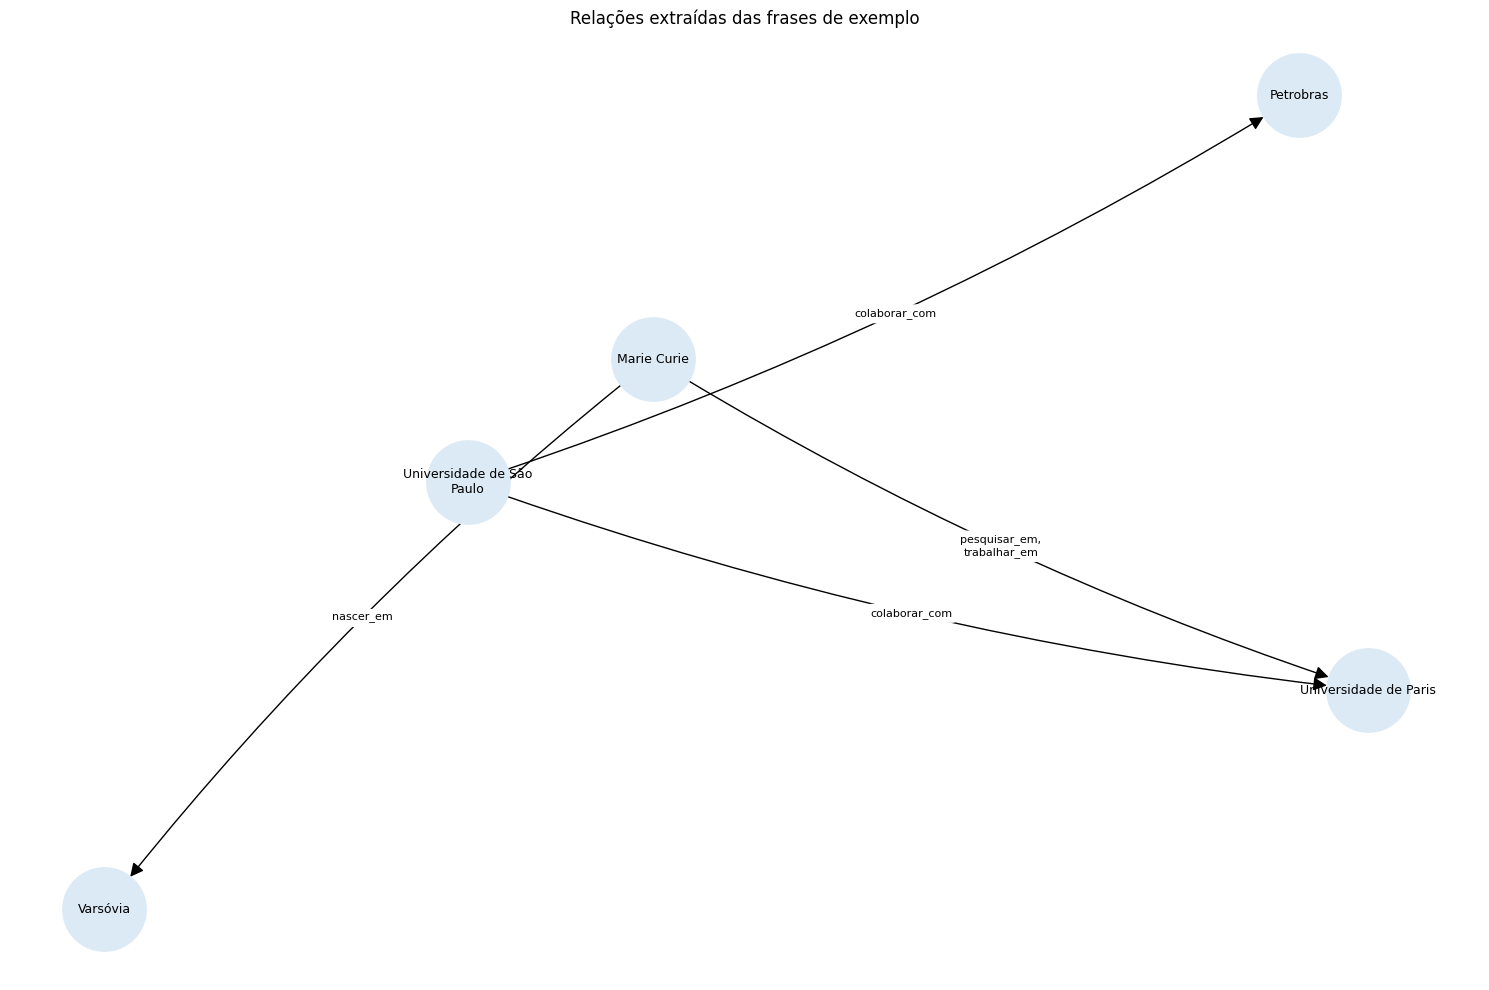

Nós: 5 | Pares direcionados: 4


In [ ]:
import textwrap


def desenhar_grafo(tabela, titulo):
    grafo = nx.DiGraph()
    for (origem, destino), grupo in tabela.groupby(["sujeito", "objeto"], sort=True):
        grafo.add_edge(origem, destino,
                       relação=", ".join(sorted(set(grupo["relação"]))))
    fig, ax = plt.subplots(figsize=(15, 10))
    pos = nx.spring_layout(grafo, seed=42, k=1.8)
    nx.draw_networkx_nodes(grafo, pos, node_size=3600, node_color="#dceaf5", ax=ax)
    nomes = {n: textwrap.fill(n, width=22) for n in grafo.nodes}
    nx.draw_networkx_labels(grafo, pos, labels=nomes, font_size=9, ax=ax)
    # Desenhar uma aresta por vez permite separar relações recíprocas.
    for origem, destino, dados in grafo.edges(data=True):
        curva = 0.25 if grafo.has_edge(destino, origem) else 0.06
        nx.draw_networkx_edges(grafo, pos, edgelist=[(origem, destino)],
                               arrows=True, arrowsize=20, node_size=3600,
                               connectionstyle=f"arc3,rad={curva}", ax=ax)
        nx.draw_networkx_edge_labels(
            grafo, pos, edge_labels={(origem, destino):
                textwrap.fill(dados["relação"], width=24)},
            font_size=8, rotate=False, node_size=3600,
            connectionstyle=f"arc3,rad={curva}", ax=ax)
    ax.set_title(titulo)
    ax.axis("off")
    plt.tight_layout()
    plt.show()
    print(f"Nós: {grafo.number_of_nodes()} | Pares direcionados: {grafo.number_of_edges()}")
    return grafo

G_exemplos = desenhar_grafo(relacoes_df, "Relações extraídas das frases de exemplo")


## 7. Exemplo final: um texto com dois parágrafos
Agora aplicaremos o pipeline ao **mesmo texto completo**: segmentar sentenças, reconhecer entidades, extrair relações, inspecionar a tabela e construir o grafo.

O texto contém pronomes, coordenações e referências indiretas de propósito. Esses casos permitem observar o que as regras não conseguem integrar.


In [ ]:
texto_longo = """
Marie Curie nasceu em Varsóvia e estudou em Paris.
Ela trabalhou na Universidade de Paris e realizou pesquisas sobre radioatividade.
Pierre Curie colaborou com Marie Curie em diversos experimentos.
Marie Curie recebeu o Prêmio Nobel de Física em 1903 e o Prêmio Nobel de Química em 1911.

A Universidade de Paris manteve atividades científicas em Paris durante esse período.
Pesquisadores ligados à instituição colaboraram com cientistas de diferentes países.
"""


### 7.1. Segmentar o texto e localizar entidades
O parser fornece `doc.sents`. A tabela combina as sentenças e suas entidades, evitando repetir a listagem global de menções. Uma lista vazia indica que o NER não reconheceu entidades naquela sentença.


In [ ]:
doc_longo = nlp(texto_longo.strip())
sentencas = [sent.text.strip() for sent in doc_longo.sents]
pd.DataFrame([
    {"sentença": i, "texto": sent.text.strip(),
     "entidades": [(ent.text, ent.label_) for ent in sent.ents]}
    for i, sent in enumerate(doc_longo.sents, start=1)
])


,sentença,texto,entidades
0,1,Marie Curie nasceu em Varsóvia e estudou em Pa...,"[(Marie Curie, PER), (Varsóvia, LOC), (Paris, ..."
1,2,Ela trabalhou na Universidade de Paris e reali...,"[(Universidade de Paris, LOC)]"
2,3,Pierre Curie colaborou com Marie Curie em dive...,"[(Pierre Curie, PER), (Marie Curie, PER)]"
3,4,Marie Curie recebeu o Prêmio Nobel de Física e...,"[(Marie Curie, PER), (Prêmio Nobel de Física, ..."
4,5,A Universidade de Paris manteve atividades cie...,"[(Universidade de Paris, LOC), (Paris, LOC)]"
5,6,Pesquisadores ligados à instituição colaborara...,[]


### 7.2. Extrair e inspecionar as relações
Aplicamos a função a cada sentença e preservamos o número e o texto original para auditoria. Compare cada tripla com sua frase antes de interpretar o grafo: uma saída estruturada pode conter erros ou perder informações.


In [ ]:
resultados = [
    extrair_relacoes(sentenca).assign(sentença=i, texto=sentenca)
    for i, sentenca in enumerate(sentencas, start=1)
]
relacoes_texto_df = (pd.concat(resultados, ignore_index=True) if resultados
                    else pd.DataFrame(columns=["sujeito", "relação", "objeto",
                                               "sentença", "texto"]))
relacoes_texto_df[["sentença", "sujeito", "relação", "objeto", "texto"]]


,sentença,sujeito,relação,objeto,texto
0,1,Marie Curie,nascer_em,Varsóvia,Marie Curie nasceu em Varsóvia e estudou em Pa...
1,2,Ela,trabalhar_em,Universidade de Paris,Ela trabalhou na Universidade de Paris e reali...
2,3,Pierre Curie,colaborar_com,Marie Curie,Pierre Curie colaborou com Marie Curie em dive...
3,3,Pierre Curie,colaborar_em,experimentos,Pierre Curie colaborou com Marie Curie em dive...
4,4,Marie Curie,receber,Prêmio Nobel de Física,Marie Curie recebeu o Prêmio Nobel de Física e...
5,4,Marie Curie,receber_em,1903,Marie Curie recebeu o Prêmio Nobel de Física e...
6,5,Universidade de Paris,manter,atividades científicas em Paris,A Universidade de Paris manteve atividades cie...
7,5,Universidade de Paris,manter_durante,período,A Universidade de Paris manteve atividades cie...
8,6,Pesquisadores ligados à instituição,colaborar,cientistas de diferentes países,Pesquisadores ligados à instituição colaborara...


### 7.3. Construir o grafo final
A visualização integra as triplas efetivamente extraídas; não acrescentamos manualmente relações ausentes. Um nó “Ela” não será ligado automaticamente a Marie Curie, pois não implementamos resolução de correferência. Nem todas as entidades reconhecidas aparecem como argumentos de uma relação.


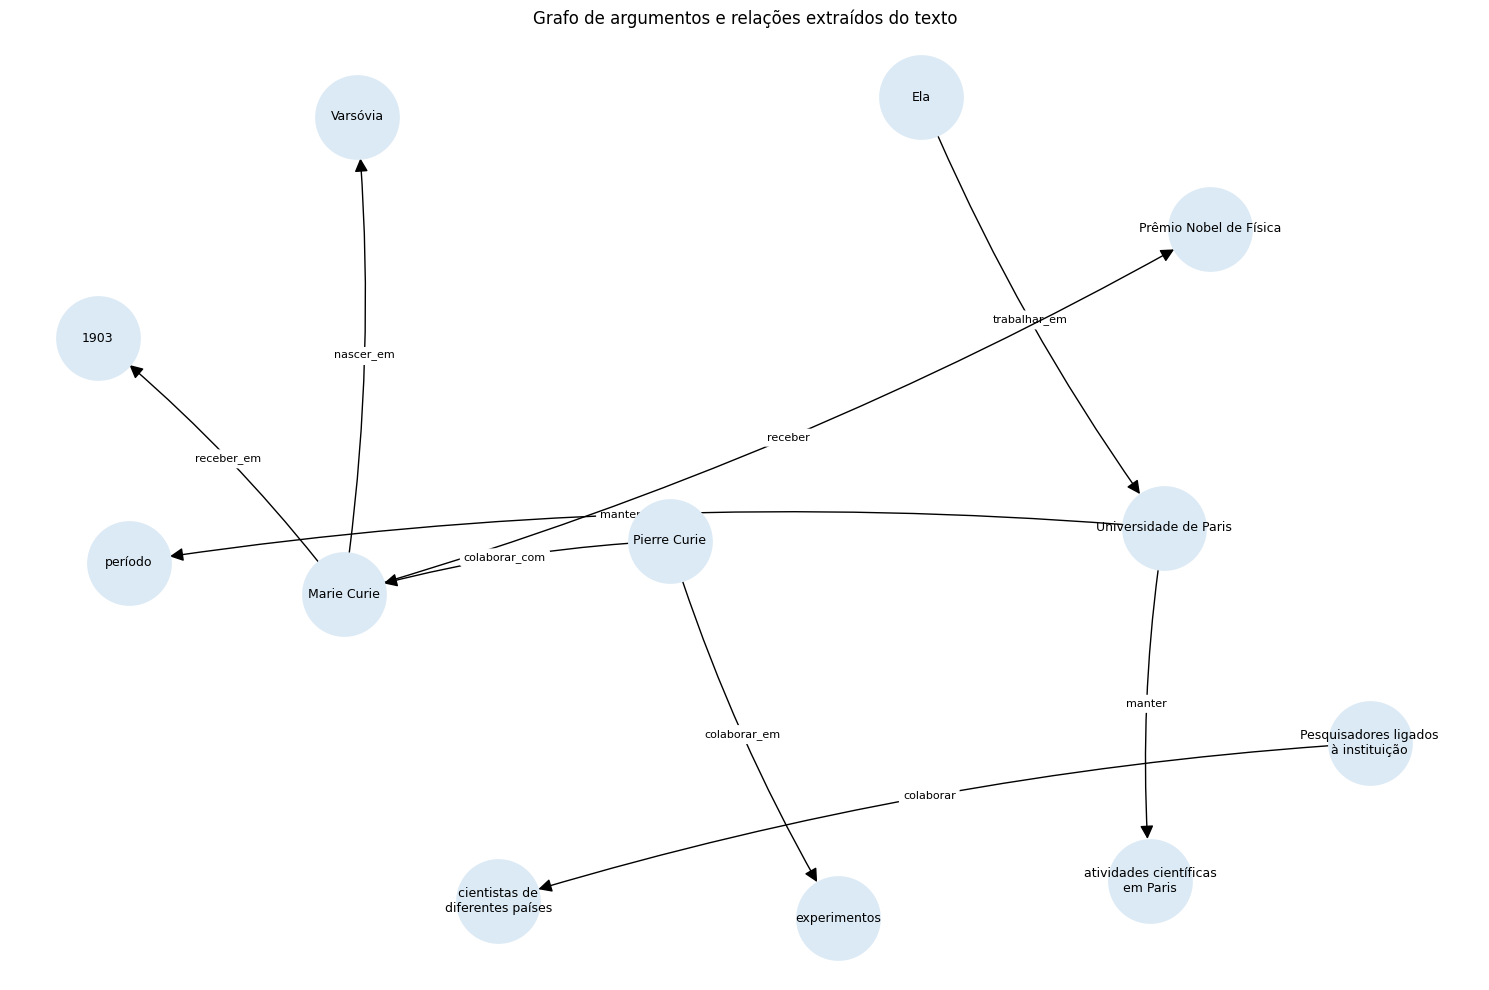

Nós: 12 | Pares direcionados: 9


In [ ]:
G_texto = desenhar_grafo(relacoes_texto_df, "Grafo de argumentos e relações extraídos do texto")


## 8. Interpretar o resultado e seus limites
O percurso foi **texto → dependências/NER → relações → normalização local → grafo**. A extração final é uma aproximação baseada em regras, não uma verificação de fatos nem uma representação semântica completa.

- **Correferência:** “Ela” e “a instituição” não são resolvidos para seus antecedentes.
- **Coordenação e sujeito omitido:** “nasceu … e estudou …” pode produzir apenas parte das relações; prêmios coordenados também exigem regras adicionais.
- **Papéis semânticos:** a voz passiva não é convertida para agente–ação–paciente; modificadores ou entidades internas podem gerar argumentos inadequados.
- **Contexto e normalização:** tempo, negação e modalidade não são representados; lemas não unificam sinônimos, e NER não resolve siglas ou homônimos.
- **Propagação de erros:** falhas do parser e do NER afetam as triplas. Agrupar arestas simplifica o desenho, mas oculta repetições e eventos distintos; a tabela conserva as sentenças de origem.

**Discussão:** identifique uma tripla adequada, uma informação ausente e um nó que deveria ser integrado a outro. Indique qual etapa precisaria melhorar em cada caso.
